In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

In [3]:
df = pd.read_csv("Mall_Customers.csv")

In [4]:
df.shape

(200, 5)

In [5]:
df.describe()

,CustomerID,Age,Annual_Income_(k$),Spending_Score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   CustomerID          200 non-null    int64 
 1   Genre               200 non-null    object
 2   Age                 200 non-null    int64 
 3   Annual_Income_(k$)  200 non-null    int64 
 4   Spending_Score      200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [8]:
df.isnull().sum()

CustomerID            0
Genre                 0
Age                   0
Annual_Income_(k$)    0
Spending_Score        0
dtype: int64

In [9]:
df.head()

,CustomerID,Genre,Age,Annual_Income_(k$),Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [11]:
df.drop('CustomerID',axis=1,inplace=True)

In [12]:
df['Genre']=df['Genre'].map({'Male':1,'Female':0})

In [15]:
X = df[['Annual_Income_(k$)','Spending_Score']]

In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

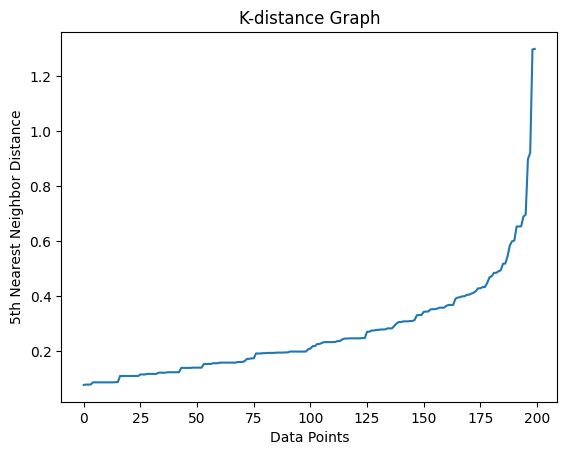

In [17]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit=neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:,4], axis=0)
plt.plot(distances)
plt.xlabel("Data Points")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("K-distance Graph")
plt.show()

In [18]:
model = DBSCAN(eps=0.5, min_samples=5)
clusters = model.fit_predict(X_scaled)

In [19]:
df["Cluster"] = clusters

In [20]:
df['Cluster'].value_counts()

Cluster
 0    157
 1     35
-1      8
Name: count, dtype: int64

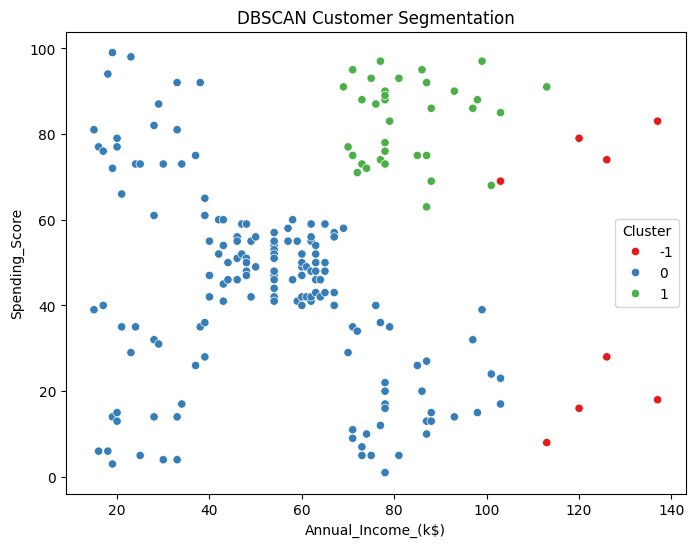

In [21]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Annual_Income_(k$)"],
    y=df["Spending_Score"],
    hue=df["Cluster"],
    palette="Set1"
)

plt.title("DBSCAN Customer Segmentation")

plt.show()